<div dir="rtl" align="right">

# ⚽ Master Scout — מחברת בדיקת המערכת

**פרויקט גמר · סדנת AI & ML · קורס 277302**

מחברת זו היא **בדיקת שפיות** לכל שלבי עיבוד הנתונים. היא טוענת את הטבלאות
שנבנו, מציגה אותן, ומריצה את בדיקות האיכות — כדי לוודא שהכול עובד כמו שצריך.

### איך להריץ
1. הפעל את הסביבה: `conda activate masterscout`
2. פתח את המחברת ב-Jupyter/VSCode ולחץ **Run All** (חובה — כדי שכל הגרפים והטבלאות ייווצרו).

> שמות שחקנים/קבוצות מוצגים באנגלית; ההסברים בעברית.
> כל שלב מופרד ב-Markdown משלו. הערות נוספות מופיעות גם בתוך הקוד.

</div>

In [1]:
# --- הגדרות וסביבה ---
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# שורש הפרויקט = תיקיית האב של notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
print("project root:", ROOT)
print("processed files:", [p.name for p in PROC.glob("*.csv")])

project root: /Users/ronbiton/Desktop/אקדמרון/אקדמרון - סדנת ai ml/סדנת ai ml - פרויקט פאדי
processed files: ['player_event_stats.csv', 'player_match_stats.csv', 'clean_events.csv', 'final_scouting_table.csv', 'clean_players.csv']


<div dir="rtl" align="right">

## שלב 1 — מבנה הנתונים ומיפוי קודים

שני מקורות נתונים גולמיים. נציג את הגדלים ואת טבלת מיפוי קודי האירועים
(שעליה מבוססות כל העמודות הבינאריות בהמשך).

</div>

In [2]:
from data_loader import load_players_data, load_events_data

players_raw = load_players_data(RAW / "male_players.csv")   # מסונן ל-FC24 בלבד
events_raw = load_events_data(RAW / "events.csv")

print(f"FC24 players: {players_raw.shape[0]:,} שורות × {players_raw.shape[1]} עמודות")
print(f"events:       {events_raw.shape[0]:,} שורות × {events_raw.shape[1]} עמודות")
print(f"events — משחקים ייחודיים: {events_raw['id_odsp'].nunique():,} | "
      f"שחקנים: {events_raw['player'].nunique():,} | גולים: {int(events_raw['is_goal'].sum()):,}")

FC24 players: 18,350 שורות × 52 עמודות
events:       941,009 שורות × 18 עמודות
events — משחקים ייחודיים: 9,074 | שחקנים: 6,118 | גולים: 24,446


In [3]:
# טבלת מיפוי קודי event_type (מתוך docs/01_schema.md) — מוצגת כ-DataFrame
from clean_events import (EVENT_TYPE_NAMES, BODYPART_NAMES,
                          LOCATION_NAMES, IN_BOX_LOCATIONS)

map_df = pd.DataFrame(
    sorted(EVENT_TYPE_NAMES.items()), columns=["code", "event_type_name"]
)
map_df

,code,event_type_name
0,1,Attempt
1,2,Corner
2,3,Foul
3,4,Yellow card
4,5,Second yellow card
5,6,Red card
6,7,Substitution
7,8,Free kick won
8,9,Offside
9,10,Hand ball


<div dir="rtl" align="right">

## שלב 2 — ניתוח חוקר (EDA)

סטטיסטיקה תיאורית, אחוזי ערכים חסרים, וגרפים. נבדוק את הממצא המרכזי:
**החוסר של 11% בסטטים הוא בגלל שוערים**, לא בעיית איכות.

</div>

In [4]:
# סטטיסטיקה תיאורית — שחקני FC24
key_cols = ["age", "overall", "potential", "value_eur", "wage_eur",
            "pace", "shooting", "passing", "dribbling", "defending", "physic"]
desc = players_raw[key_cols].describe().T[["mean", "50%", "std", "min", "max"]]
desc = desc.rename(columns={"50%": "median"}).round(2)
desc

,mean,median,std,min,max
age,25.27,25.0,4.76,16.0,43.0
overall,65.82,66.0,6.82,47.0,91.0
potential,71.09,71.0,6.22,48.0,94.0
value_eur,2837585.21,1000000.0,7562793.87,10000.0,185000000.0
wage_eur,8723.39,3000.0,18707.24,500.0,350000.0
pace,68.37,69.0,10.77,27.0,97.0
shooting,52.58,55.0,13.90,19.0,93.0
passing,57.49,58.0,9.90,25.0,94.0
dribbling,62.84,64.0,9.45,28.0,94.0
defending,52.09,57.0,16.03,15.0,89.0


In [5]:
# אחוזי ערכים חסרים — שחקני FC24
miss = players_raw.isna().sum()
miss = (pd.DataFrame({"missing": miss, "missing_pct": (miss / len(players_raw) * 100).round(2)})
        .query("missing > 0").sort_values("missing_pct", ascending=False))
miss

,missing,missing_pct
pace,2045,11.14
shooting,2045,11.14
passing,2045,11.14
dribbling,2045,11.14
defending,2045,11.14
physic,2045,11.14
release_clause_eur,1280,6.98
value_eur,100,0.54
wage_eur,87,0.47
club_name,87,0.47


In [6]:
# אימות: האם כל ה-NaN ב-pace שייכים לשוערים?
gk = players_raw["player_positions"].str.startswith("GK")
print(f"שוערים (GK כעמדה ראשונה): {gk.sum():,}")
print(f"מתוכם pace חסר:           {players_raw.loc[gk, 'pace'].isna().sum():,}")
print(f"שחקני שדה עם pace חסר:    {players_raw.loc[~gk, 'pace'].isna().sum():,}  ← צריך להיות 0")

שוערים (GK כעמדה ראשונה): 2,045
מתוכם pace חסר:           2,045
שחקני שדה עם pace חסר:    0  ← צריך להיות 0


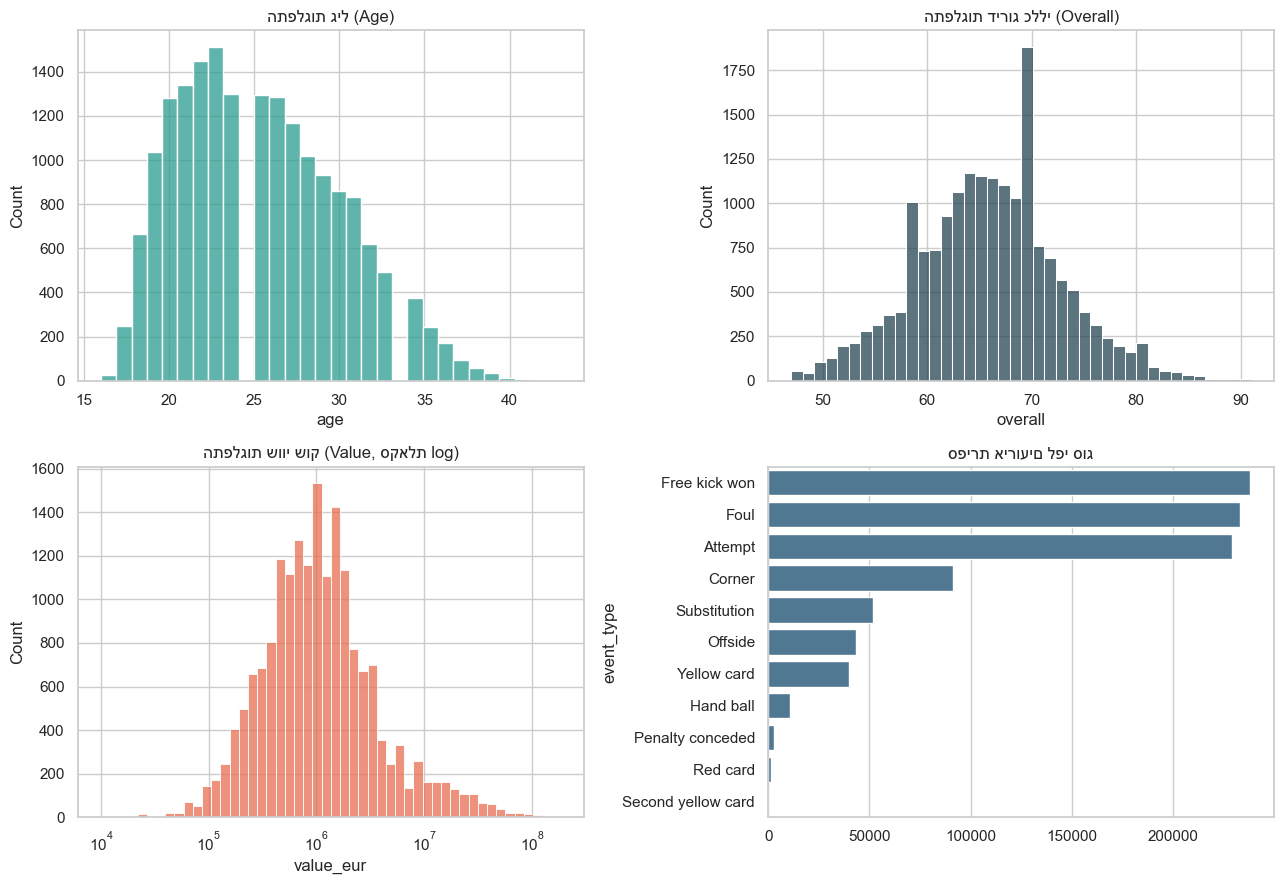

In [7]:
# גרפים בסיסיים (4 גרפים — נטמעים במחברת)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(players_raw["age"].dropna(), bins=30, color="#2a9d8f", ax=axes[0, 0])
axes[0, 0].set_title("התפלגות גיל (Age)")

sns.histplot(players_raw["overall"].dropna(), bins=40, color="#264653", ax=axes[0, 1])
axes[0, 1].set_title("התפלגות דירוג כללי (Overall)")

val = players_raw.loc[players_raw["value_eur"] > 0, "value_eur"]
sns.histplot(val, bins=50, color="#e76f51", log_scale=(True, False), ax=axes[1, 0])
axes[1, 0].set_title("התפלגות שווי שוק (Value, סקאלת log)")

ev_counts = events_raw["event_type"].map(EVENT_TYPE_NAMES).value_counts()
sns.barplot(x=ev_counts.values, y=ev_counts.index, color="#457b9d", ax=axes[1, 1])
axes[1, 1].set_title("ספירת אירועים לפי סוג")

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

**קריאה:** `value_eur` מוטה ימינה בקיצוניות (ממוצע ≫ חציון) — זה מצדיק גלאי
"מציאות" בשלב 11. `overall` מתפלג כפעמון סביב 66 — מתאים לדמיון/קלאסטרינג.

</div>

<div dir="rtl" align="right">

## שלב 3 — ניקוי שחקנים (clean_players)

טבלה נקייה ברמת שחקן + עמודות ציון מחושבות. נבדוק: אין כפילויות, אין NaN
בעמודות מפתח, קיבוץ עמדות נכון, וניקוי שמות תקין.

</div>

In [8]:
clean_players = pd.read_csv(PROC / "clean_players.csv")
print(f"clean_players: {clean_players.shape[0]:,} שורות × {clean_players.shape[1]} עמודות")
clean_players[["short_name", "long_name", "clean_name", "position_group",
               "age", "overall", "ability_score", "value_eur",
               "market_efficiency_score"]].head()

clean_players: 18,350 שורות × 57 עמודות


,short_name,long_name,clean_name,position_group,age,overall,ability_score,value_eur,market_efficiency_score
0,K. Mbappé,Kylian Mbappé Lottin,kylian mbappe lottin,Forward,24,91,84.20,181500000.0,-0.08
1,E. Haaland,Erling Braut Haaland,erling braut haaland,Forward,22,91,81.60,185000000.0,-0.23
2,K. De Bruyne,Kevin De Bruyne,kevin de bruyne,Midfielder,32,91,83.85,103000000.0,-0.04
3,L. Messi,Lionel Andrés Messi Cuccittini,lionel andres messi cuccittini,Forward,36,90,79.60,41000000.0,0.18
4,K. Benzema,Karim Benzema,karim benzema,Forward,35,90,79.60,51000000.0,-0.12


In [9]:
# בדיקות איכות — שלב 3
print("כפילויות player_id:", int(clean_players["player_id"].duplicated().sum()), " ← 0")
print("NaN ב-overall:    ", int(clean_players["overall"].isna().sum()), " ← 0")
print("NaN ב-value_eur:  ", int(clean_players["value_eur"].isna().sum()), " (סוכנים חופשיים)")
print("\nחלוקת position_group:")
print(clean_players["position_group"].value_counts(dropna=False).to_string())
print("\nממוצע ability_score לפי קבוצה:")
print(clean_players.groupby("position_group")["ability_score"].mean().round(2).to_string())

כפילויות player_id: 0  ← 0
NaN ב-overall:     0  ← 0
NaN ב-value_eur:   100  (סוכנים חופשיים)

חלוקת position_group:
position_group
Midfielder    6673
Defender      6174
Forward       3458
GK            2045

ממוצע ability_score לפי קבוצה:
position_group
Defender      62.69
Forward       62.06
GK            64.31
Midfielder    62.84


In [10]:
# מועמדים ל"מציאה" בקרב שחקני שדה (סיגנל גולמי; הדגל האמיתי בשלב 11)
outfield = clean_players[clean_players["position_group"] != "GK"]
cols = ["short_name", "position_group", "age", "overall",
        "ability_score", "value_eur", "market_efficiency_score"]
outfield.nlargest(8, "market_efficiency_score")[cols]

,short_name,position_group,age,overall,ability_score,value_eur,market_efficiency_score
3968,Miguel Lopes,Defender,36,71,70.95,325000.0,74.92
4124,D. Bocanegra,Defender,36,71,69.60,325000.0,71.19
3955,M. Cáceres,Defender,36,71,69.10,325000.0,69.62
10324,Wang Gang,Defender,34,65,67.25,250000.0,67.15
6970,Jeong Woon,Defender,34,68,69.65,400000.0,66.67
5763,C. Avinel,Defender,36,69,67.10,250000.0,66.58
7126,Júnior Morais,Defender,36,68,67.30,275000.0,65.93
5005,H. Orzán,Midfielder,35,70,70.25,450000.0,65.87


<div dir="rtl" align="right">

## שלב 4 — ניקוי אירועים (clean_events)

תרגום קודים לטקסט + 12 עמודות בינאריות. הקובץ גדול (~209MB) — נטען רק את
העמודות הדרושות לבדיקה. נוודא: כל הקודים תורגמו, וסכומי הגולים מתאימים.

</div>

In [11]:
check_cols = ["clean_name", "event_type", "event_type_name", "bodypart_name",
              "is_shot", "is_goal", "is_key_pass", "is_box_shot",
              "is_left_foot", "is_right_foot", "is_header", "is_on_target"]
clean_events = pd.read_csv(PROC / "clean_events.csv", usecols=check_cols, low_memory=False)
print(f"clean_events: {clean_events.shape[0]:,} שורות (טענו {clean_events.shape[1]} עמודות נבחרות)")

print("\nסכומי עמודות בינאריות:")
for c in ["is_shot", "is_goal", "is_key_pass", "is_box_shot", "is_on_target"]:
    print(f"  {c:<14}: {int(clean_events[c].sum()):,}")

untranslated = clean_events.loc[clean_events["event_type"].notna()
                                & clean_events["event_type_name"].isna()]
print(f"\nשורות event_type לא מתורגמות: {len(untranslated)}  ← 0")

clean_events: 941,009 שורות (טענו 12 עמודות נבחרות)

סכומי עמודות בינאריות:
  is_shot       : 229,135
  is_goal       : 24,446
  is_key_pass   : 167,859
  is_box_shot   : 123,255
  is_on_target  : 78,014

שורות event_type לא מתורגמות: 0  ← 0


In [12]:
# גולים לפי חלק גוף (בדיקת שפיות — ימין שמאל ראש)
goals_bp = clean_events.loc[clean_events["is_goal"] == 1, "bodypart_name"].value_counts(dropna=False)
print(goals_bp.to_string())

bodypart_name
Right foot    13451
Left foot      6758
Head           4236
NaN               1


<div dir="rtl" align="right">

## שלב 5 — סטטיסטיקת שחקן × משחק (player_match_stats)

אגרגציה לרמת שחקן-במשחק. נוודא **התאמת גולים** מול clean_events, ונציג את
משחקי ה-"ברייס" (2+ גולים) המובילים — אמורים להיות שחקני עילית אמיתיים.

</div>

In [13]:
pms = pd.read_csv(PROC / "player_match_stats.csv")
print(f"player_match_stats: {pms.shape[0]:,} שורות × {pms.shape[1]} עמודות")
print(f"שחקנים ייחודיים: {pms['clean_name'].nunique():,} | משחקים: {pms['id_odsp'].nunique():,}")
pms.head()

player_match_stats: 228,072 שורות × 15 עמודות
שחקנים ייחודיים: 6,106 | משחקים: 9,074


,clean_name,id_odsp,shots,goals,key_passes,box_shots,shots_on_target,left_foot_shots,right_foot_shots,header_shots,yellow_cards,red_cards,fouls,through_ball_assists,match_team
0,a a igo la3pez,00Wld37M/,0,0,0,0,0,0,0,0,0,0,0,0,Granada
1,a a igo la3pez,0hK6x8H2/,0,0,0,0,0,0,0,0,0,0,0,0,Getafe
2,a a igo la3pez,6Pu7yska/,0,0,0,0,0,0,0,0,0,0,0,0,Barcelona
3,a a igo la3pez,6ZyWozj1/,0,0,0,0,0,0,0,0,0,0,0,0,Mallorca
4,a a igo la3pez,AmJJpF2g/,0,0,0,0,0,0,0,0,0,0,0,0,Levante


In [14]:
# בדיקות איכות — שלב 5
print("סך גולים:", int(pms["goals"].sum()), " (מול 24,446 ב-clean_events; הפרש = גולים ללא שחקן)")
print("מקס' גולים לשחקן במשחק:", int(pms["goals"].max()))
print("שורות goals > shots:", int((pms["goals"] > pms["shots"]).sum()), " ← 0")
print("שורות box_shots > shots:", int((pms["box_shots"] > pms["shots"]).sum()), " ← 0")

print(f"\nמשחקי ברייס (2+ גולים): {int((pms['goals'] >= 2).sum()):,}")
pms[pms["goals"] >= 2].nlargest(5, "goals")[["clean_name", "id_odsp", "goals", "shots"]]

סך גולים: 24441  (מול 24,446 ב-clean_events; הפרש = גולים ללא שחקן)
מקס' גולים לשחקן במשחק: 5
שורות goals > shots: 0  ← 0
שורות box_shots > shots: 0  ← 0

משחקי ברייס (2+ גולים): 2,362


,clean_name,id_odsp,goals,shots
34519,carlos eduardo,hvccPEon/,5,8
44443,cristiano ronaldo,WxAtGffN/,5,7
44491,cristiano ronaldo,pA3O7Kmo/,5,13
68550,falcao,dIf75igU/,5,5
158953,miroslav klose,SlFSSgoh/,5,6


<div dir="rtl" align="right">

## שלב 6 — אגרגציה לשחקן וציוני ביצוע (player_event_stats)

שורה אחת לכל שחקן: סכומים, per_match, יחסים (0–1), וארבעה ציונים מחושבים.
**ולידציה מרכזית:** מובילי המעורבות ההתקפית אמורים להיות חלוצי עילית אמיתיים.

</div>

In [15]:
pes = pd.read_csv(PROC / "player_event_stats.csv")
print(f"player_event_stats: {pes.shape[0]:,} שורות × {pes.shape[1]} עמודות")
pes[["clean_name", "matches", "total_goals", "goals_per_match",
     "attacking_involvement_score", "creative_score",
     "discipline_score", "foot_balance_score"]].head()

player_event_stats: 6,106 שורות × 27 עמודות


,clean_name,matches,total_goals,goals_per_match,attacking_involvement_score,creative_score,discipline_score,foot_balance_score
0,a a igo la3pez,16,0,0.0,6.31,7.46,100.0,NaN
1,a a igo la3pez montaa a,1,0,0.0,NaN,NaN,NaN,NaN
2,a a igo lekue,5,0,0.0,6.31,7.46,100.0,NaN
3,a a scar de marcos,1,0,0.0,NaN,NaN,NaN,NaN
4,a ngelo da costa,22,0,0.0,6.31,7.46,100.0,NaN


In [16]:
# בדיקות איכות — שלב 6
print("התאמת goals_per_match = total_goals/matches:",
      bool(np.allclose(pes["total_goals"] / pes["matches"],
                       pes["goals_per_match"], equal_nan=True)))
for c in ["shot_accuracy", "conversion_rate", "box_shot_rate"]:
    v = pes[c].dropna()
    print(f"  {c}: min={v.min():.3f} max={v.max():.3f}  ← בטווח 0..1")
print("יחסים מעל 1:", int((pes[["shot_accuracy", "conversion_rate", "box_shot_rate"]] > 1).sum().sum()), " ← 0")
print("שחקנים עם 5+ משחקים:", int((pes["matches"] >= 5).sum()))

התאמת goals_per_match = total_goals/matches: True
  shot_accuracy: min=0.000 max=1.000  ← בטווח 0..1
  conversion_rate: min=0.000 max=1.000  ← בטווח 0..1
  box_shot_rate: min=0.000 max=1.000  ← בטווח 0..1
יחסים מעל 1: 0  ← 0
שחקנים עם 5+ משחקים: 4862


In [17]:
# ולידציה: מובילי המעורבות ההתקפית = חלוצי עילית?
cols = ["clean_name", "matches", "total_goals", "goals_per_match",
        "attacking_involvement_score", "creative_score"]
pes.nlargest(5, "attacking_involvement_score")[cols]

,clean_name,matches,total_goals,goals_per_match,attacking_involvement_score,creative_score
1212,cristiano ronaldo,177,198,1.118644,100.00,100.00
3510,lionel messi,178,205,1.151685,99.98,99.96
5395,sergio aguero,95,75,0.789474,99.96,99.98
3653,luis suarez,106,96,0.905660,99.94,99.92
6097,zlatan ibrahimovic,171,153,0.894737,99.92,99.88


<div dir="rtl" align="right">

## שלב 7 — הטבלה המרכזית (final_scouting_table)

מיזוג פרופיל FC24 + ביצועי אירועים. **הרגע שבו מתגלה היקף ה-PoC:** כמה
שחקנים בפועל קיימים בשני המקורות (פער השנים 2012–2017 מול 2023).

</div>

In [18]:
final = pd.read_csv(PROC / "final_scouting_table.csv")
n = len(final); matched = int(final["has_event_data"].sum())
print(f"final_scouting_table: {n:,} שורות × {final.shape[1]} עמודות")
print(f"כפילויות player_id: {int(final['player_id'].duplicated().sum())}  ← 0")
print(f"has_event_data=True:  {matched:,}  ({matched/n*100:.1f}%)")
print(f"has_event_data=False: {n-matched:,}  ({(n-matched)/n*100:.1f}%)")

final_scouting_table: 18,350 שורות × 78 עמודות


כפילויות player_id: 0  ← 0
has_event_data=True:  902  (4.9%)
has_event_data=False: 17,448  (95.1%)


In [19]:
# כיסוי נתוני אירועים לפי קבוצת עמדה
cov = final.groupby("position_group")["has_event_data"].agg(["sum", "count"])
cov["pct"] = (cov["sum"] / cov["count"] * 100).round(1)
cov

,sum,count,pct
position_group,,,
Defender,294,6174,4.8
Forward,204,3458,5.9
GK,91,2045,4.4
Midfielder,313,6673,4.7


In [20]:
# בדיקת שפיות: שחקני FC24 מובילים שהתאימו לנתוני אירועים — הסטטיסטיקה הגיונית?
cols = ["short_name", "clean_name", "overall", "has_event_data", "matches", "total_goals"]
final[final["has_event_data"]].nlargest(8, "overall")[cols]

,short_name,clean_name,overall,has_event_data,matches,total_goals
2,K. De Bruyne,kevin de bruyne,91,True,128.0,33.0
4,K. Benzema,karim benzema,90,True,156.0,85.0
5,R. Lewandowski,robert lewandowski,90,True,171.0,124.0
7,H. Kane,harry kane,90,True,95.0,65.0
15,V. van Dijk,virgil van dijk,89,True,50.0,4.0
21,A. Griezmann,antoine griezmann,88,True,183.0,80.0
22,J. Oblak,jan oblak,88,True,27.0,0.0
27,G. Donnarumma,gianluigi donnarumma,87,True,18.0,0.0


<div dir="rtl" align="right">

**מסקנה:** רק ~5% מהשחקנים קיימים בשני המקורות — זו המגבלה המרכזית (פער
השנים). אבל ההתאמה **מדויקת** (Lewandowski 124 גולים, Kane 65) ו-902 שחקנים
מספיקים בשפע לדמיון/קלאסטרינג/חריגות. החיפוש לפי פרופיל עובד על כל 18,350.

</div>

<div dir="rtl" align="right">

## שלב 8 — פונקציות חיפוש (search.py)

6 פונקציות חיפוש פרמטריות. כל סף הוא פרמטר. נריץ כמה דוגמאות ונוודא שהתוצאות
הגיוניות (דמבלה כדו-רגלי, Lewandowski בברייסים).

</div>

In [21]:
import search as S

# [1] כנפיים צעירים ומהירים (חיפוש פרופיל — על כל 18,350)
S.search_players_by_profile(final, position_group="Forward", max_age=22,
                            min_pace=85, max_value_eur=30_000_000, top_n=5)[
    ["short_name", "age", "overall", "value_eur", "preferred_foot", "has_event_data"]]

,short_name,age,overall,value_eur,preferred_foot,has_event_data
0,N. Madueke,21,77,23500000.0,Left,False
1,B. Johnson,22,76,15000000.0,Right,False
2,R. Højlund,20,76,18000000.0,Left,False
3,J. Bakayoko,20,75,12500000.0,Left,False
4,M. Mudryk,22,75,12500000.0,Right,False


In [22]:
# [2] שחקנים התקפיים (ביצועי אירועים) — מובילי attacking_involvement
S.search_attacking_players(final, max_value_eur=40_000_000, top_n=5)[
    ["short_name", "age", "overall", "total_goals", "goals_per_match",
     "attacking_involvement_score"]]

,short_name,age,overall,total_goals,goals_per_match,attacking_involvement_score
0,E. Džeko,37,83,40.0,0.425532,99.84
1,O. Giroud,36,82,71.0,0.496503,99.65
2,C. Austin,33,65,25.0,0.462963,99.55
3,J. Rodriguez,33,73,19.0,0.395833,99.03
4,C. Immobile,33,85,48.0,0.393443,98.93


In [23]:
# [5] דו-רגליים (20+ בעיטות) — דמבלה אמור לצוץ
S.search_two_footed_players(final, top_n=5)[
    ["short_name", "position_group", "foot_balance_score", "total_shots"]]

,short_name,position_group,foot_balance_score,total_shots
0,O. Dembélé,Forward,100.00,73.0
1,M. Weiser,Defender,100.00,26.0
2,A. Izzo,Defender,100.00,20.0
3,S. Verdi,Forward,97.67,88.0
4,S. Coleman,Defender,97.37,84.0


In [24]:
# [6] שחקנים עם 5+ ברייסים — Lewandowski אמור להוביל
S.find_players_with_min_braces(final, min_braces=5, top_n=5)[
    ["short_name", "total_goals", "matches_with_2_plus_goals", "goals_per_match"]]

,short_name,total_goals,matches_with_2_plus_goals,goals_per_match
0,R. Lewandowski,124.0,35.0,0.725146
1,A. Lacazette,88.0,19.0,0.502857
2,A. Griezmann,80.0,18.0,0.437158
3,K. Benzema,85.0,16.0,0.544872
4,H. Kane,65.0,16.0,0.684211


<div dir="rtl" align="right">

## שלב 9 — דמיון שחקנים ב-Cosine (similarity.py) · שימוש #1

נרמול פיצ'רים (StandardScaler) + Cosine. כולל **השוואת מודלים** קריטית
לפרק 5+6: עם קטגוריית עמדה מול בלי. דמיון בטווח 0–1.

</div>

In [25]:
import importlib, similarity as SIM
importlib.reload(SIM)

# שחקנים הדומים ל-Kevin De Bruyne (WITH category — אותה עמדה)
sim_res, tgt = SIM.find_similar_players(final, "De Bruyne", top_n=8, same_position=True)
print(f"מטרה: {tgt['short_name']} ({tgt['position_group']}, overall {tgt['overall']})")
print("טווח דמיון:", sim_res['similarity'].min(), "..", sim_res['similarity'].max(), "← 0..1")
sim_res

מטרה: K. De Bruyne (Midfielder, overall 91)
טווח דמיון: 0.9903 .. 0.9956 ← 0..1


,short_name,position_group,age,overall,value_eur,similarity,reason
0,Bruno Fernandes,Midfielder,28,88,92000000.0,0.9956,"similar pace, physic, shooting"
1,Brais Méndez,Midfielder,26,81,30000000.0,0.9949,"similar defending, pace, physic"
2,Y. Belhanda,Midfielder,33,75,3500000.0,0.9942,"similar pace, defending, physic"
3,B. Bourigeaud,Midfielder,29,81,25000000.0,0.9933,"similar pace, defending, physic"
4,A. Mac Allister,Midfielder,24,82,39500000.0,0.9915,"similar pace, dribbling, defending"
5,G. Lo Celso,Midfielder,27,81,29500000.0,0.9912,"similar pace, dribbling, defending"
6,C. De Ketelaere,Midfielder,22,76,15000000.0,0.9907,"similar pace, physic, defending"
7,Chiquinho,Midfielder,27,76,8000000.0,0.9903,"similar pace, defending, physic"


<div dir="rtl" align="right">

### השוואת מודלים — עם קטגוריה מול בלי
מובילי הדמיון ל-De Bruyne **בלי** הגבלת עמדה — שימו לב אם צצים שחקנים מעמדות אחרות.

</div>

In [26]:
with_cat, without_cat, overlap = SIM.compare_with_without_category(final, "De Bruyne", top_n=8)
print(f"חפיפה בין שתי הרשימות: {overlap}/8")
without_cat[["short_name", "position_group", "overall", "similarity", "reason"]]

חפיפה בין שתי הרשימות: 5/8


,short_name,position_group,overall,similarity,reason
0,Brais Méndez,Midfielder,81,0.9964,"similar defending, pace, physic"
1,B. Bourigeaud,Midfielder,81,0.9957,"similar pace, defending, physic"
2,Bruno Fernandes,Midfielder,88,0.9956,"similar pace, physic, shooting"
3,C. De Ketelaere,Midfielder,76,0.9948,"similar pace, physic, defending"
4,A. Barák,Midfielder,78,0.9945,"similar defending, pace, physic"
5,Y. Belhanda,Midfielder,75,0.9940,"similar pace, defending, physic"
6,Gustavo Sauer,Forward,74,0.9935,"similar pace, physic, dribbling"
7,I. Ilić,Midfielder,76,0.9933,"similar defending, pace, physic"


<div dir="rtl" align="right">

## שלב 10 — קיבוץ סגנונות משחק ב-K-Means (clustering.py) · שימוש #1

קיבוץ לסגנונות. בחירת **k בשיטת Elbow**. כל קלאסטר מתואר מילולית. ולידציה:
קלאסטר העילית אמור להכיל את Messi/Mbappé/De Bruyne.

</div>

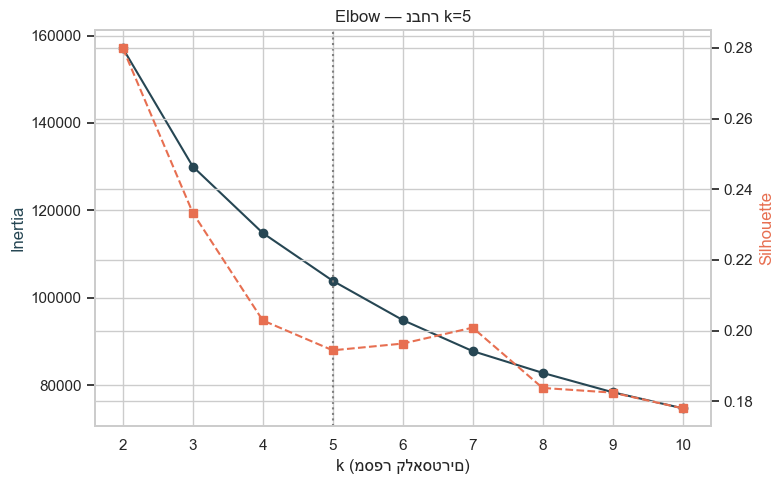

In [27]:
import clustering as CL
importlib.reload(CL)

# שיטת Elbow — inertia + silhouette לכל k (גרף נטמע במחברת)
elbow = CL.elbow_analysis(final, save_path=None)
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(elbow["k"], elbow["inertia"], "o-", color="#264653")
ax1.set_xlabel("k (מספר קלאסטרים)"); ax1.set_ylabel("Inertia", color="#264653")
ax2 = ax1.twinx()
ax2.plot(elbow["k"], elbow["silhouette"], "s--", color="#e76f51")
ax2.set_ylabel("Silhouette", color="#e76f51")
ax1.axvline(5, ls=":", color="gray"); plt.title("Elbow — נבחר k=5")
plt.tight_layout(); plt.show()

In [28]:
# טוענים את הטבלה עם cluster_id (נכתב ע"י clustering.py) ומתארים כל קלאסטר
clustered = pd.read_csv(PROC / "final_scouting_table.csv")
desc = pd.DataFrame([CL.describe_cluster(clustered, c) for c in range(CL.DEFAULT_K)])
desc[["cluster_id", "label", "size", "sample_players"]]

,cluster_id,label,size,sample_players
0,0,defensive / fast,3763,"[R. Araujo, A. Rüdiger, R. Varane, F. Tomori, ..."
1,1,goal-scoring / fast,3822,"[F. Zampedri, Barrenetxea, G. Orban, C. Desser..."
2,2,technical / playmaking,3574,"[K. Mbappé, K. De Bruyne, E. Haaland, L. Messi..."
3,3,defensive / physical,2646,"[W. Orban, R. Le Normand, J. Aidoo, B. Mee, I...."
4,4,playmaking / defensive,2500,"[Rodri, Casemiro, Rúben Dias, M. de Ligt, T. K..."


In [29]:
# הקלאסטר ה"טכני" — אמור להכיל את שחקני העילית
tech = desc.sort_values("size")  # just to access; show players of the elite cluster
for c in range(CL.DEFAULT_K):
    members = clustered[clustered["cluster_id"] == c]
    if {"l. messi", "k. mbappé"} & set(members["short_name"].str.lower()):
        print(f"קלאסטר העילית = {c} ({CL.describe_cluster(clustered, c)['label']})")
        break
CL.get_players_from_cluster(clustered, c, top_n=8)

קלאסטר העילית = 2 (technical / playmaking)


,short_name,position_group,age,overall,value_eur
0,K. Mbappé,Forward,24,91,181500000.0
1,K. De Bruyne,Midfielder,32,91,103000000.0
2,E. Haaland,Forward,22,91,185000000.0
3,L. Messi,Forward,36,90,41000000.0
4,K. Benzema,Forward,35,90,51000000.0
5,R. Lewandowski,Forward,34,90,58000000.0
6,H. Kane,Forward,29,90,119500000.0
7,Vini Jr.,Forward,22,89,158500000.0


<div dir="rtl" align="right">

### מפת הקלאסטרים — היטל PCA דו-ממדי (צבע = סגנון משחק)
המחשה ויזואלית של הפרדת הסגנונות.

</div>

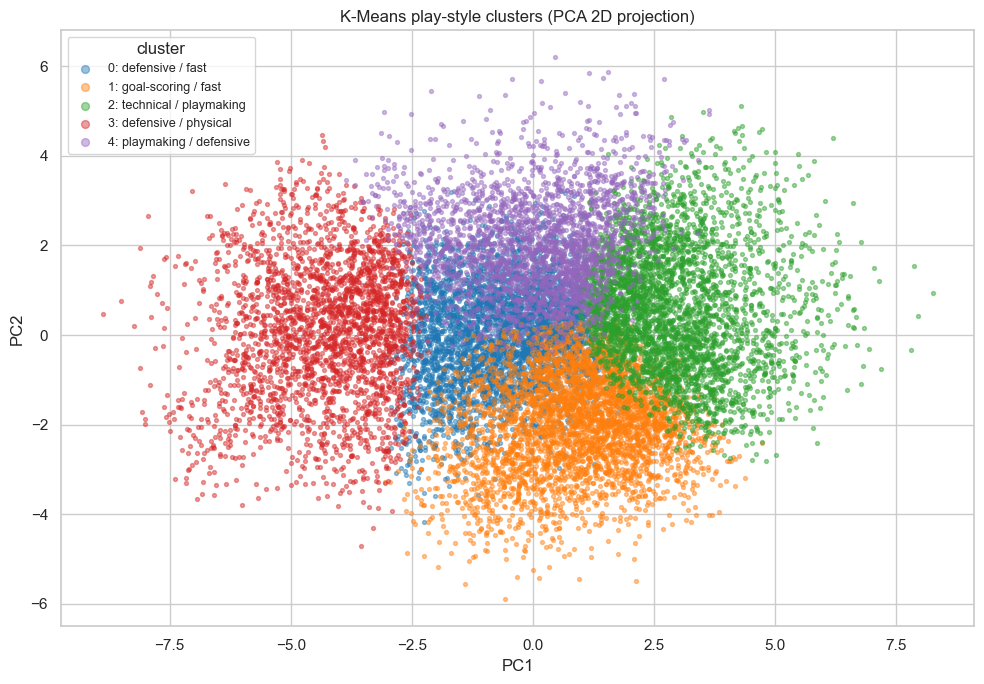

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
CL.plot_clusters_2d(clustered, ax=ax)
plt.tight_layout(); plt.show()

<div dir="rtl" align="right">

## שלב 11 — גילוי חריגות (anomaly.py) · שימוש #2

(א) מציאות (יכולת גבוהה במחיר נמוך), (ב) חריגות פרופיל-מול-ביצוע. כולל
**השוואת מודלים**: Isolation Forest מול DBSCAN מול One-Class SVM.

</div>

In [31]:
import anomaly as AN
importlib.reload(AN)

# [2a] מציאות עילית-וזולות (min_overall=78) — בלמים אגדיים שערכם ירד
AN.detect_bargain_players(clustered, min_overall=78, top_n=8)

,short_name,position_group,age,overall,potential,value_eur,market_efficiency_score,anomaly_score
0,G. Chiellini,Defender,38,80,80,3800000.0,8.28,-0.0176
1,Sergio Ramos,Defender,37,83,83,6500000.0,5.32,-0.0338
2,Thiago Silva,Defender,38,84,84,7500000.0,4.06,-0.0447
3,Dante,Defender,39,78,78,2500000.0,3.66,-0.0023
4,F. Acerbi,Defender,35,83,83,9500000.0,3.46,-0.0175
5,Jesús Navas,Defender,37,80,80,4700000.0,2.78,-0.0059
6,M. Hummels,Defender,34,83,83,12000000.0,2.54,-0.0160
7,Jordi Alba,Defender,34,83,83,13500000.0,2.39,-0.0171


In [32]:
# [2b] חריגות פרופיל-מול-ביצוע (שחקנים עם נתוני אירועים)
AN.detect_profile_performance_anomalies(clustered, top_n=8)

,short_name,position_group,age,overall,attacking_involvement_score,goals_per_match,conversion_rate,direction,anomaly_score
0,T. Blackett,Defender,29,65,18.06,0.125000,1.000000,unusual profile,-0.1630
1,R. Lewandowski,Forward,34,90,99.90,0.725146,0.195893,elite (extreme but consistent output),-0.1377
2,H. Kane,Forward,29,90,99.88,0.684211,0.184136,elite (extreme but consistent output),-0.1277
3,K. Benzema,Forward,35,90,99.53,0.544872,0.195853,elite (extreme but consistent output),-0.1031
4,M. Caldara,Defender,29,70,58.34,0.250000,0.500000,unusual profile,-0.0920
5,J. Lascelles,Defender,29,75,55.46,0.200000,0.500000,unusual profile,-0.0825
6,M. Hector,Defender,30,69,47.75,0.166667,0.500000,unusual profile,-0.0796
7,A. Lacazette,Forward,32,83,97.41,0.502857,0.225064,unusual profile,-0.0645


In [33]:
# השוואת מודלים — IF מול DBSCAN מול One-Class SVM (אותו מרחב פיצ'רים)
cmp = AN.compare_if_vs_dbscan(clustered)
pd.DataFrame([cmp]).T.rename(columns={0: "count"})

,count
isolation_forest,365
dbscan,14
one_class_svm,394
IF∩DBSCAN,14
IF∩OCSVM,160
all_three,14
total_players,18250


<div dir="rtl" align="right">

**מסקנה:** DBSCAN מסמן רק 14 חריגות (הנתונים 'ענן רציף' בלי פערי צפיפות) בעוד
IF/OCSVM מסמנים ~2%. זו ולידציה שבחירת Isolation Forest נכונה לנתונים האלה.

</div>

<div dir="rtl" align="right">

## ✅ סיכום — מצב הטבלאות

טבלת סטטוס של כל קבצי העיבוד שנבנו עד כה.

</div>

In [34]:
summary = pd.DataFrame([
    {"stage": "3", "file": "clean_players.csv", "rows": len(clean_players),
     "entity": "שחקן (FC24)"},
    {"stage": "4", "file": "clean_events.csv", "rows": len(clean_events),
     "entity": "אירוע במשחק"},
    {"stage": "5", "file": "player_match_stats.csv", "rows": len(pms),
     "entity": "שחקן × משחק"},
    {"stage": "6", "file": "player_event_stats.csv", "rows": len(pes),
     "entity": "שחקן (מצרפי)"},
    {"stage": "7", "file": "final_scouting_table.csv", "rows": len(final),
     "entity": "שחקן (טבלה מרכזית)"},
])
summary["status"] = "✅"
summary

,stage,file,rows,entity,status
0,3,clean_players.csv,18350,שחקן (FC24),✅
1,4,clean_events.csv,941009,אירוע במשחק,✅
2,5,player_match_stats.csv,228072,שחקן × משחק,✅
3,6,player_event_stats.csv,6106,שחקן (מצרפי),✅
4,7,final_scouting_table.csv,18350,שחקן (טבלה מרכזית),✅


<div dir="rtl" align="right">

### הצעדים הבאים (יתווספו למחברת בהמשך)
- שלב 6 — `player_event_stats` (שורה לשחקן + ציונים מצרפיים)
- שלב 7 — `final_scouting_table` (מיזוג פרופיל + ביצועים)
- שלבים 8–11 — חיפוש, דמיון (Cosine), קלאסטרינג (K-Means), חריגות (Isolation Forest)
- שלבים 12–15 — סוכן GPT, דוחות, בדיקות, ופריסה חיה

</div>